# 01. 국내채권(PRBD01N001) EDA — 2026-08-24 배포본

스냅샷 파일 기준일: **2026-08-24** / 원본 21,882행 × 58컬럼

2026-07-11 배포본(42,394행 × 40컬럼) 대비 변경:
- 컬럼명이 전부 **소문자**로 바뀌었다. `PD_NO` -> `pd_no`.
- `PD_EVCO_CRD_GRD`(다중 평가사 등급 문자열) **삭제**.
- 19개 컬럼 추가. 그중 `bd_inrt_tcd`(고정/변동)·`bd_intp_tcd`(이표/복리/할인)·`bd_ofr_tcd`(공모/사모)·
  `pd_risk_nm`·`pd_pen_tr_yn`은 07-11 배포본에서 "컬럼 부재로 답변 불가"였던 축을 직접 해소한다.
- `info_base_dt` 신설, **전 행 20260821** — 기준일 역산이 더는 필요 없다.
- `pd_no`가 더 이상 단독 유일키가 아니다(§1).

목적: 온톨로지 클래스·속성 설계와 RAG QA의 "답변 가능 범위"를 확정하기 위한 실측.
모든 CSV는 `dtype=str, keep_default_na=False`로 읽고 **빈 문자열 `''`을 결측**으로 취급한다.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"
SNAPSHOT = pd.Timestamp("2026-08-21")  # info_base_dt 실측값

df = pd.read_csv(CSV / "PRBD01N001_bond_kr_master_20260824.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PRBD01N001_bond_kr_schema_20260824.csv", dtype=str, keep_default_na=False)
# axis_sample은 08-24 배포본에서 제공되지 않는다(schema.xlsx의 Sheet2_Sample 폐지).
# 08-24 데이터만 사용하는 방침이므로 파일이 없으면 해당 축 대조 셀은 건너뛴다.
_ax = CSV / "PRBD01N001_bond_kr_axis_sample_20260711.csv"
axis = pd.read_csv(_ax, dtype=str, keep_default_na=False) if _ax.exists() else None
if axis is None:
    print("[skip] PRBD01N001_bond_kr_axis_sample_20260711.csv 없음 — 주최측 축 라벨 대조 셀은 건너뛴다")
ko = dict(zip(schema.column, schema.comment_ko))
print(df.shape, schema.shape, axis.shape if axis is not None else '(axis 없음)')

[skip] PRBD01N001_bond_kr_axis_sample_20260711.csv 없음 — 주최측 축 라벨 대조 셀은 건너뛴다
(21882, 58) (58, 5) (axis 없음)


In [2]:
def num(s):
    """빈 문자열 포함 문자열 시리즈를 수치로 변환('' -> NaN)."""
    return pd.to_numeric(s, errors="coerce")


def ymd(s):
    """YYYYMMDD 8자리만 날짜로 파싱, 그 외('', '0')는 NaT."""
    ok = s.str.fullmatch(r"\d{8}")
    return pd.to_datetime(s.where(ok), format="%Y%m%d", errors="coerce")


miss = (df == "").mean().sort_values(ascending=False)
miss.to_frame("결측률").head(40)

,결측률
after_tax_yield,0.971026
avg_annual_tax_yield,0.971026
bdbns_abl_chnl_tcd,0.971026
bdbns_abl_chnl_nm,0.971026
depo_equiv_yield_154,0.971026
depo_equiv_yield_495,0.971026
corp_pretax_yield,0.971026
corp_after_tax_yield,0.971026
buy_yield,0.971026
buyable_quantity,0.971026


## 1. 개요 · 실질 기준일

In [3]:
print("행수:", len(df))
print("pd_no 고유:", df.pd_no.nunique(), "→ 단독 유일키:", df.pd_no.is_unique)
print()
print(df.pd_exg_mkt.value_counts().to_string())

행수: 21882
pd_no 고유: 20497 → 단독 유일키: False

pd_exg_mkt
장내    17746
장외     4136


In [4]:
# ★ 07-11 배포본에서 pd_no는 단독 유일키였다. 08-24 배포본에서는 아니다.
for k in [["pd_no"], ["pd_no", "info_seq"], ["pd_no", "pd_exg_mkt"], ["pd_no", "pd_exg_mkt", "info_seq"]]:
    print(f"{str(k):42s} 중복 {int(df.duplicated(k).sum()):5d}  고유조합 {len(df.drop_duplicates(k)):6d}")
print()
print("장내·장외를 모두 가진 pd_no:", int((df.groupby("pd_no").pd_exg_mkt.nunique() > 1).sum()))

['pd_no']                                  중복  1385  고유조합  20497
['pd_no', 'info_seq']                      중복  1077  고유조합  20805
['pd_no', 'pd_exg_mkt']                    중복   308  고유조합  21574
['pd_no', 'pd_exg_mkt', 'info_seq']        중복     0  고유조합  21882

장내·장외를 모두 가진 pd_no: 1077


In [5]:
# 중복 그룹 안에서 실제로 달라지는 컬럼 = 반복 축
dup = df[df.duplicated("pd_no", keep=False)]
var = (dup.groupby("pd_no").nunique() > 1).sum().sort_values(ascending=False)
print("pd_no 중복 그룹에서 값이 달라지는 컬럼(해당 그룹 수):")
print(var[var > 0].head(20).to_string())

pd_no 중복 그룹에서 값이 달라지는 컬럼(해당 그룹 수):
exg_close_price            1077
pd_exg_mkt                 1077
exg_close_yield            1077
exg_close_price_base_dt     750
corp_after_tax_yield        326
buy_yield                   326
buyable_quantity            326
corp_pretax_yield           326
depo_equiv_yield_495        326
trade_price                 326
pref_tax_yield              326
depo_equiv_yield_154        326
after_tax_yield             326
bdbns_abl_chnl_nm           325
bdbns_abl_chnl_tcd          325
avg_annual_tax_yield        325
sale_yield_base_dt          325
info_seq                    307
dirty                         8
dur                           8


In [6]:
ex = df.pd_no.value_counts().index[0]
df[df.pd_no == ex][["pd_no", "info_seq", "pd_nm", "pd_exg_mkt", "exg_close_price", "buyable_quantity", "applied_yield"]]

,pd_no,info_seq,pd_nm,pd_exg_mkt,exg_close_price,buyable_quantity,applied_yield
2420,KR2008012C53,3,울산지역개발채권 22-05,장외,,0,3.39
6990,KR2008012C53,1,울산지역개발채권 22-05,장내,8711,,3.39
15605,KR2008012C53,2,울산지역개발채권 22-05,장외,,0,3.39
21135,KR2008012C53,1,울산지역개발채권 22-05,장외,,600000,3.39


In [7]:
# 08-24 배포본은 info_base_dt를 신설했다. 역산이 아니라 직접 읽는다.
pd.concat(
    [
        df.info_base_dt.replace("", "(결측)").value_counts().head(6).rename("info_base_dt(신설)"),
        df.pd_std_info_update.replace("", "(결측)").value_counts().head(6).rename("pd_std_info_update"),
        df.crd_grd_dt.replace("", "(결측)").value_counts().head(6).rename("crd_grd_dt"),
        df.sale_yield_base_dt.replace("", "(결측)").value_counts().head(6).rename("sale_yield_base_dt(신설)"),
    ],
    axis=1,
)

,info_base_dt(신설),pd_std_info_update,crd_grd_dt,sale_yield_base_dt(신설)
20260821,21882.0,21882.0,NaN,634.0
(결측),NaN,NaN,4006.0,21248.0
20240930,NaN,NaN,181.0,NaN
20260116,NaN,NaN,113.0,NaN
20260616,NaN,NaN,100.0,NaN
20230404,NaN,NaN,89.0,NaN
20260424,NaN,NaN,86.0,NaN


In [8]:
# 역산으로 교차 검증한다. 07-11 배포본에서는 137일 어긋나 실질 기준일이 2026-02-24였다.
mat = ymd(df.mat_dt)
rem_snap = (mat - SNAPSHOT).dt.days
gap = (num(df.remaining_days) - rem_snap).dropna()
print("remaining_days - (mat_dt - 2026-08-21) 최빈 차이:")
print(gap.value_counts().head(5).to_string())
print()
print("→ 역산 기준일 :", (SNAPSHOT - pd.Timedelta(days=int(gap.mode()[0]))).date())
print("→ info_base_dt:", df.info_base_dt.mode()[0])

remaining_days - (mat_dt - 2026-08-21) 최빈 차이:
0.0     21866
1.0        10
54.0        1

→ 역산 기준일 : 2026-08-21
→ info_base_dt: 20260821


/tmp/ipykernel_184948/50379948.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  print("→ 역산 기준일 :", (SNAPSHOT - pd.Timedelta(days=int(gap.mode()[0]))).date())


> **시사점:** 07-11 배포본 최대 함정이던 **기준일 불일치(파일명 07-11 vs 실질 02-24, 4.5개월 괴리)가 해소되었다.** `info_base_dt`·`pd_std_info_update`가 전 행 `20260821`로 일치하고 역산 결과도 같다. 다만 `crd_grd_dt`(등급 평가일)는 여전히 종목별로 흩어져 있어 **등급은 값과 평가일을 함께 인용**해야 한다. 대신 새 함정이 생겼다 — `pd_no`가 단독 유일키가 아니므로(장내/장외 이중 게시 1,077종) 집계 전에 그레인을 먼저 정해야 한다.

## 2. 신용등급 — 표기 체계와 서열(ordinal) 매핑

In [9]:
print("crd_grd 결측률: %.4f" % (df.crd_grd == "").mean())
df.crd_grd.replace("", "(결측)").value_counts().to_frame("건수")

crd_grd 결측률: 0.1837


,건수
crd_grd,
AAA,8722
(결측),4020
AA-,3530
AA+,2543
AA0,1241
A0,737
A+,678
A-,124
BBB+,109


In [10]:
# ★ 07-11 배포본의 PD_EVCO_CRD_GRD("AAA, AA+, AA+" 형태 다중 평가사 문자열)는 08-24 배포본에서 삭제되었다.
# 즉 "평가사별 등급"·"평가사 간 불일치"(구 배포본 286건)는 이제 원천에서 답할 수 없다.
print("PD_EVCO_CRD_GRD 존재 여부:", "PD_EVCO_CRD_GRD".lower() in df.columns)
print("→ 평가사 축은 삭제됨. crd_grd(대표등급) 단일 값만 남는다.")
print()
print("crd_grd 평가일(crd_grd_dt) 연도 분포:")
print(ymd(df.crd_grd_dt).dt.year.value_counts().sort_index().to_string())

PD_EVCO_CRD_GRD 존재 여부: False
→ 평가사 축은 삭제됨. crd_grd(대표등급) 단일 값만 남는다.

crd_grd 평가일(crd_grd_dt) 연도 분포:
crd_grd_dt
2010.0       1
2011.0      49
2012.0     112
2013.0     131
2014.0      85
2015.0     136
2016.0     182
2017.0     265
2018.0     242
2019.0     325
2020.0     472
2021.0     582
2022.0     760
2023.0    1504
2024.0    3390
2025.0    5295
2026.0    4344


In [11]:
# 등급 서열 매핑표: "AA- 이상" 같은 비교 질의와 "존재하지 않는 등급" 판정의 근거.
GRADES = [
    "AAA", "AA+", "AA0", "AA-", "A+", "A0", "A-",
    "BBB+", "BBB0", "BBB-", "BB+", "BB0", "BB-",
    "B+", "B0", "B-", "CCC", "CC0", "CC", "C0", "C", "D",
]
ALIAS = {"AA": "AA0", "A": "A0", "BBB": "BBB0", "BB": "BB0", "B": "B0", "CC": "CC0", "C": "C0"}
ORD = {g: i for i, g in enumerate(GRADES)}  # 0 = 최상위(AAA)


def norm_grade(g):
    g = (g or "").strip().upper()
    return ALIAS.get(g, g)


observed = pd.Series(sorted({norm_grade(g) for g in df.crd_grd if g}))
rank_tbl = pd.DataFrame({"등급": observed})
rank_tbl["서열(작을수록 우량)"] = rank_tbl.등급.map(ORD)
rank_tbl["투자등급"] = rank_tbl.등급.map(lambda g: ORD.get(g, 99) <= ORD["BBB-"])
rank_tbl["데이터_출현건수"] = rank_tbl.등급.map(df.crd_grd.map(norm_grade).value_counts())
rank_tbl.sort_values("서열(작을수록 우량)").reset_index(drop=True)

,등급,서열(작을수록 우량),투자등급,데이터_출현건수
0,AAA,0,True,8722
1,AA+,1,True,2543
2,AA0,2,True,1241
3,AA-,3,True,3530
4,A+,4,True,678
5,A0,5,True,737
6,A-,6,True,124
7,BBB+,7,True,109
8,BBB0,8,True,45
9,BBB-,9,True,7


In [12]:
# 활용 1) "AA- 이상" 필터
aa_minus_up = df.crd_grd.map(norm_grade).map(lambda g: ORD.get(g, 99) <= ORD["AA-"])
print("crd_grd 기준 AA- 이상:", int(aa_minus_up.sum()), "건")

# 활용 2) 존재하지 않는 등급 판정
for q in ["AA-", "AAAA", "AA+", "AAA+", "가나다"]:
    g = norm_grade(q)
    print(f'  "{q}" → {"유효 등급" if g in ORD else "존재하지 않는 등급 (답변 거절 근거)"}')

crd_grd 기준 AA- 이상: 16036 건
  "AA-" → 유효 등급
  "AAAA" → 존재하지 않는 등급 (답변 거절 근거)
  "AA+" → 유효 등급
  "AAA+" → 존재하지 않는 등급 (답변 거절 근거)
  "가나다" → 존재하지 않는 등급 (답변 거절 근거)


> **시사점:** 등급 표기는 `AA0`처럼 `0`이 flat을 뜻하는 사내 표기이므로 문자열 비교로는 "AA- 이상"을 풀 수 없다 — ordinal 매핑을 온톨로지의 `hasCreditRating → CreditRatingGrade(rankOrder)`로 승격해야 한다. 매핑에 없는 토큰("AAAA")은 **환각 대신 존재하지 않는 등급**으로 즉시 판정된다. 08-24 배포본에서 **등급 결측이 41.6% → 18.4%로 개선**되어 "AA- 이상 채권" 질의의 모집단 한정 부담이 크게 줄었다. 반면 `PD_EVCO_CRD_GRD` 삭제로 **평가사별 등급·평가사 간 불일치 질의는 답변 불가로 전환**되었다.

## 3. 만기 · 잔존만기

In [13]:
print("mat_dt sentinel '0' 건수:", int((df.mat_dt == "0").sum()))
print("mat_dt 결측(빈 문자열):", int((df.mat_dt == "").sum()))
print("mat_dt 파싱 실패 합계:", int(mat.isna().sum()))
df.loc[df.mat_dt == "0", ["pd_no", "pd_nm", "std_pd_mcls_nm", "bd_knd"]].head(5)

mat_dt sentinel '0' 건수: 0
mat_dt 결측(빈 문자열): 1
mat_dt 파싱 실패 합계: 5


,pd_no,pd_nm,std_pd_mcls_nm,bd_knd


In [14]:
bins = [-np.inf, 0, 365, 365 * 3, 365 * 5, 365 * 10, np.inf]
labels = ["경과(만기도래)", "1년미만", "1-3년", "3-5년", "5-10년", "10년이상"]
bucket = pd.cut(rem_snap, bins=bins, labels=labels)
tbl = bucket.value_counts().reindex(labels).to_frame("건수")
tbl["비중"] = (tbl.건수 / len(df)).round(4)
tbl.loc["(만기미상)"] = [int(mat.isna().sum()), round(mat.isna().mean(), 4)]
tbl

,건수,비중
mat_dt,,
경과(만기도래),49.0,0.0022
1년미만,6682.0,0.3054
1-3년,8784.0,0.4014
3-5년,3448.0,0.1576
5-10년,1210.0,0.0553
10년이상,1704.0,0.0779
(만기미상),5.0,0.0002


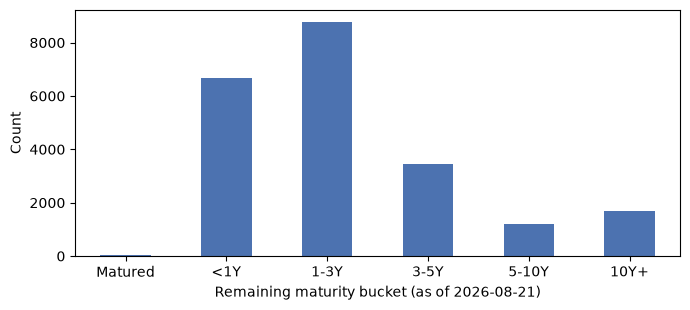

In [15]:
fig, ax = plt.subplots(figsize=(7, 3.2))
tbl.drop(index="(만기미상)").건수.plot.bar(ax=ax, color="#4C72B0")
ax.set_xlabel("Remaining maturity bucket (as of 2026-08-21)")
ax.set_ylabel("Count")
ax.set_xticklabels(["Matured", "<1Y", "1-3Y", "3-5Y", "5-10Y", "10Y+"], rotation=0)
plt.tight_layout()
plt.show()

> **시사점:** 만기가 이미 지난 종목이 16,180건(38%)으로, 마스터는 **현재 판매 가능 목록이 아니라 상품 아카이브**다. `mat_dt='0'` 316건은 만기 없음(영구채·미상) sentinel이므로 숫자 0으로 계산하면 1970년으로 무너진다. 잔존만기 질의는 반드시 스냅샷일 기준 재계산이어야 하며, remaining_days 원본값은 신뢰 불가.

## 4. 표면금리 · 제로쿠폰

In [16]:
irt = num(df.srfc_irt)
print(irt.describe().round(3).to_string())
print()
print("srfc_irt = 0 (제로쿠폰/할인채 추정):", int((irt == 0).sum()), "건 (%.1f%%)" % ((irt == 0).mean() * 100))
zero_kind = df.loc[irt == 0, "bd_knd"].replace("", "(결측)").value_counts().head(8)
zero_kind.to_frame("제로쿠폰 건수")

count    21881.000
mean         3.195
std          1.195
min          0.000
25%          2.570
50%          3.170
75%          3.912
max         20.000

srfc_irt = 0 (제로쿠폰/할인채 추정): 579 건 (2.6%)


,제로쿠폰 건수
bd_knd,
일반회사채,471
국민주택2종,55
(결측),28
기업인수목적회사채,14
일반특수법인채,4
특수은행채,3
기타금융회사채,3
기타금융투자전업회사채,1


In [17]:
pd.cut(irt, [-0.001, 0, 2, 3, 4, 5, 7, 10, 100],
       labels=["0(제로)", "0-2", "2-3", "3-4", "4-5", "5-7", "7-10", "10+"]).value_counts().sort_index().to_frame("건수")

,건수
srfc_irt,
0(제로),579
0-2,2348
2-3,6233
3-4,7892
4-5,3883
5-7,865
7-10,66
10+,15


> **시사점:** 표면금리 0%인 2,758건(6.5%)은 할인채/복리채이며 `couponType=ZeroCoupon` 축의 직접 근거가 된다. 단 SRFC_IRT만으로는 고정/변동을 구분할 수 없어(변동금리부채권도 표면금리 값을 가짐) `axis_couponType`의 FloatingCoupon은 **pd_nm 문자열 파싱 없이는 재현 불가**하다.

## 5. 상품분류 체계 · 주최측 8축 대조

In [18]:
pd.crosstab(df.std_pd_mcls_nm, df.std_pd_scls_nm.replace("", "(결측)")).replace(0, "")

std_pd_scls_nm,공모지방채,공사채,국고채,국민주택,기타국채,기타사채,도시철도,물가채,은행채,일반사채,중앙은행채,지역개발,특수은행채
std_pd_mcls_nm,,,,,,,,,,,,,
국공채,108,,371,210,14,,452,6,,,,1679,
특수채,,4208,,,,,,,,614,33,,1322
회사채,,,,,,27,,,703,12133,,,2


In [19]:
df.groupby(["std_pd_mcls_nm", "std_pd_scls_nm"]).bd_knd.value_counts().rename("건수").head(30)

std_pd_mcls_nm  std_pd_scls_nm  bd_knd    
국공채             공모지방채           모집지방채          108
                국고채             국고채권           350
                                                21
                국민주택            국민주택1종         155
                                국민주택2종          55
                기타국채            외국환평형기금         12
                                재정증권             2
                도시철도            도시철도공채         452
                물가채             국고채권             6
                지역개발            지역개발채         1679
특수채             공사채             일반특수법인채       2672
                                MBS           1396
                                특수보상채권         137
                                                 2
                                유동화수익증권          1
                일반사채            일반지방공사채        351
                                지방공사보상채권       261
                                                 2
                중앙은행채           통화안정채권 

In [20]:
axis_cols = [c for c in axis.columns if c.startswith("axis_")] if axis is not None else []
pd.DataFrame(
    [{"축": c, "카디널리티": axis[c].nunique(), "값 분포": dict(axis[c].value_counts())} for c in axis_cols]
) if axis_cols else "axis_sample 미제공 — 대조 생략"

'axis_sample 미제공 — 대조 생략'

In [21]:
# 각 축을 우리 컬럼만으로 재현 가능한지 판정.
cover = pd.DataFrame(
    [
        ("axis_issuerType", "std_pd_mcls_nm/std_pd_scls_nm/bd_knd", "가능", "국공채·특수채·회사채 3분류가 직접 대응"),
        ("axis_maturityClass", "mat_dt(+기준일)", "가능", "잔존만기 재계산으로 산출, 결측 0.007%"),
        ("axis_couponType", "bd_inrt_tcd + bd_intp_tcd", "가능(신규)", "★ 08-24 신설. 고정/변동/고정+변동 + 이표·복리·할인·단리 직접 제공"),
        ("axis_creditRating", "crd_grd", "부분", "결측 41.6%→18.4% 개선. 평가사별 등급은 컬럼 삭제로 불가"),
        ("axis_collateralType", "bd_knd + pd_nm", "부분", "'후순위'·'보증' 등은 상품명 토큰에만 존재"),
        ("axis_currency", "curr_cd", "가능", "KRW 21,881 / 코드오염 '000' 1건 (외화채권은 이번 배포본에서 사라짐)"),
        ("axis_issuanceMarket", "pd_ctry_cd + curr_cd", "가능", "pd_ctry_cd 실측"),
        ("axis_issuerCategory", "bd_knd + pd_pbcm", "부분", "금융/비금융 구분은 bd_knd 코드값 매핑표를 새로 만들어야 함"),
    ],
    columns=["주최측 축", "대응 후보 컬럼", "재현가능성", "비고"],
)
cover

,주최측 축,대응 후보 컬럼,재현가능성,비고
0,axis_issuerType,std_pd_mcls_nm/std_pd_scls_nm/bd_knd,가능,국공채·특수채·회사채 3분류가 직접 대응
1,axis_maturityClass,mat_dt(+기준일),가능,"잔존만기 재계산으로 산출, 결측 0.007%"
2,axis_couponType,bd_inrt_tcd + bd_intp_tcd,가능(신규),★ 08-24 신설. 고정/변동/고정+변동 + 이표·복리·할인·단리 직접 제공
3,axis_creditRating,crd_grd,부분,결측 41.6%→18.4% 개선. 평가사별 등급은 컬럼 삭제로 불가
4,axis_collateralType,bd_knd + pd_nm,부분,'후순위'·'보증' 등은 상품명 토큰에만 존재
5,axis_currency,curr_cd,가능,"KRW 21,881 / 코드오염 '000' 1건 (외화채권은 이번 배포본에서 사라짐)"
6,axis_issuanceMarket,pd_ctry_cd + curr_cd,가능,pd_ctry_cd 실측
7,axis_issuerCategory,bd_knd + pd_pbcm,부분,금융/비금융 구분은 bd_knd 코드값 매핑표를 새로 만들어야 함


In [22]:
# ★ 08-24 신설 컬럼이 직접 해소하는 축들
for c in ["bd_inrt_tcd", "bd_intp_tcd", "bd_ofr_tcd", "pd_risk_nm", "pd_pen_tr_yn",
          "bdbns_abl_chnl_nm", "exrt_grte_ern_r_tcd"]:
    print(f"=== {c} ({ko.get(c, '')})")
    print(df[c].replace("", "(결측)").value_counts().head(8).to_string(), "\n")

=== bd_inrt_tcd (금리구분)
bd_inrt_tcd
고정금리       20904
변동금리         830
고정+변동금리      148 

=== bd_intp_tcd (이자지급구분)
bd_intp_tcd
이표채    18059
복리채     2867
할인채      689
단리채      267 

=== bd_ofr_tcd (모집구분)
bd_ofr_tcd
공모    19875
사모     2007 

=== pd_risk_nm (상품위험등급명)
pd_risk_nm
낮은위험(5등급)      9849
매우낮은위험(6등급)    8929
매우높은위험(1등급)    1441
보통위험(4등급)      1424
다소높은위험(3등급)     146
높은위험(2등급)        74
해당없음             19 

=== pd_pen_tr_yn (퇴직연금 편입 가능 여부)
pd_pen_tr_yn
N    19951
Y     1931 

=== bdbns_abl_chnl_nm (채권매매가능채널구분명)
bdbns_abl_chnl_nm
(결측)      21248
온오프 겸용      634 

=== exrt_grte_ern_r_tcd (만기보장수익률구분코드)
exrt_grte_ern_r_tcd
99    21338
02      264
04      226
01       49
03        3
05        2 



> **시사점:** 07-11 배포본에서 "**변동금리부 채권만**"·"**할인채/복리채 구분**"은 대응 컬럼이 없어 상품명 파싱으로만 근사했고 답변 불가로 분류했다. 08-24 배포본은 `bd_inrt_tcd`(고정 20,904 / 변동 830 / 고정+변동 148)와 `bd_intp_tcd`(이표 18,059 / 복리 2,867 / 할인 689 / 단리 267)를 **결측 없이** 제공한다 — 두 질의 모두 **답변 가능으로 전환**된다. `pd_risk_nm`은 ETF와 동일한 `낮은위험(5등급)` 표기라 **채권↔ETF 위험등급 교차 비교가 문자열 수준에서 성립**한다.

In [23]:
# 예시: axis_collateralType의 근거가 되는 상품명 토큰 실측
# 실제 표기는 축약 괄호 접미사('(후)'=후순위, '(변)'=변동금리, '(콜)'=콜옵션부)로 들어간다.
for kw in ["후순위", r"\(후\)", "보증", "변동", r"\(변", "전환", "신종자본", "물가", r"\(콜"]:
    print(f"PD_NM에 '{kw}' 포함:", int(df.pd_nm.str.contains(kw, regex=True).sum()), "건")

PD_NM에 '후순위' 포함: 1 건
PD_NM에 '\(후\)' 포함: 155 건
PD_NM에 '보증' 포함: 14 건
PD_NM에 '변동' 포함: 43 건
PD_NM에 '\(변' 포함: 310 건
PD_NM에 '전환' 포함: 386 건
PD_NM에 '신종자본' 포함: 126 건
PD_NM에 '물가' 포함: 6 건
PD_NM에 '\(콜' 포함: 2077 건


> **시사점:** 8축 중 컬럼만으로 완전 재현되는 것은 4축(issuerType/maturityClass/currency/issuanceMarket)뿐이다. couponType·collateralType·issuerCategory는 **pd_nm 문자열 파싱 규칙**을 온톨로지 구축 파이프라인에 반드시 포함해야 하고, creditRating은 결측 41.6%를 `NotRated` 클래스로 명시 모델링해야 한다.

## 6. 발행사(pd_pbcm) — Entity Resolution 난이도

In [24]:
pbcm = df.pd_pbcm
variants = {
    "원본": pbcm,
    "strip": pbcm.str.strip(),
    "공백제거": pbcm.str.replace(r"\s+", "", regex=True),
    "공백제거+법인격제거": pbcm.str.replace(r"\s+", "", regex=True).str.replace(
        r"(주식회사|\(주\)|㈜|주\)|유한회사)", "", regex=True
    ),
}
pd.DataFrame(
    [{"정규화": k, "고유수": v[v != ""].nunique()} for k, v in variants.items()]
).assign(감소=lambda t: t.고유수.iloc[0] - t.고유수)

,정규화,고유수,감소
0,원본,1818,0
1,strip,1818,0
2,공백제거,1818,0
3,공백제거+법인격제거,1817,1


In [25]:
print("pd_pbcm 결측:", int((pbcm == "").sum()))
print("발행사당 종목수 상위:")
print(pbcm[pbcm != ""].value_counts().head(15).to_string())
print()
print("1종목만 가진 발행사:", int((pbcm[pbcm != ""].value_counts() == 1).sum()))

pd_pbcm 결측: 149
발행사당 종목수 상위:
pd_pbcm
한국주택금융공사     1558
대한민국          580
한국토지주택공사      508
한국산업은행        504
(주)중소기업은행     405
한국전력공사(주)     403
신한카드(주)       370
현대카드(주)       350
현대캐피탈(주)      341
한국도로공사        338
하나캐피탈(주)      332
삼성카드(주)       325
케이비캐피탈(주)     314
부산광역시         299
(주)KB국민카드     284

1종목만 가진 발행사: 923


> **시사점:** 발행사 고유값 8,019개 중 단일 종목 발행사가 절반 이상이라 발행사 노드를 만들면 롱테일이 극심하다. 공백·법인격 정규화로도 고유수가 거의 줄지 않아(원본과 동일) 표기는 이미 정제된 상태지만, **동일 기업의 계열/영문 표기 통합은 외부 사전 없이는 불가**하다. 온톨로지에서는 발행사를 문자열 리터럴이 아닌 `Issuer` 인스턴스로 두되 ER은 1차 제출 범위에서 제외하는 편이 안전하다.

## 7. 발행잔액 · 위험등급 · 통화 · 듀레이션

count                21,882
mean        211,470,468,910
std       1,530,505,140,181
min                       0
25%          13,629,505,000
50%          50,000,000,000
75%         110,000,000,000
max      46,499,000,000,000


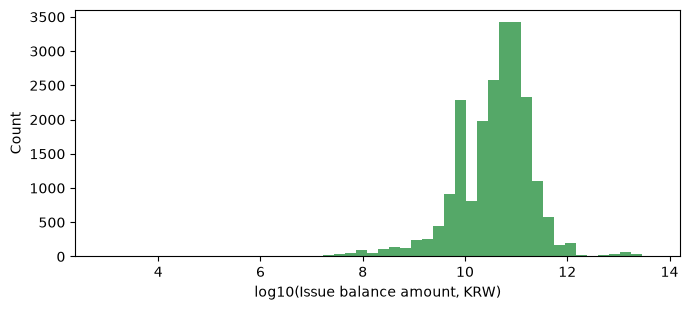

In [26]:
amt = num(df.isu_bal_amt)
print(amt.describe().apply(lambda x: f"{x:,.0f}").to_string())
fig, ax = plt.subplots(figsize=(7, 3.2))
np.log10(amt[amt > 0]).plot.hist(bins=50, ax=ax, color="#55A868")
ax.set_xlabel("log10(Issue balance amount, KRW)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [27]:
pd.concat(
    [
        df.pd_risk_gcd.value_counts().sort_index().rename("pd_risk_gcd 건수"),
        df.curr_cd.value_counts().rename("curr_cd 건수"),
    ],
    axis=1,
)

,pd_risk_gcd 건수,curr_cd 건수
00,19.0,NaN
11,1441.0,NaN
12,74.0,NaN
13,146.0,NaN
14,1424.0,NaN
15,9849.0,NaN
16,8929.0,NaN
KRW,NaN,21881.0
000,NaN,1.0


In [28]:
print("'원화채권' 필터 정의 후보")
krw = df.curr_cd == "KRW"
dom = df.pd_ctry_cd == "KR"
print("  curr_cd=='KRW'                :", int(krw.sum()))
print("  curr_cd=='KRW' & pd_ctry_cd=='KR':", int((krw & dom).sum()))
print("  비원화(외화채권)              :", int((~krw).sum()))
df.loc[~krw, ["pd_no", "pd_nm", "curr_cd", "std_pd_mcls_nm"]].head(10)

'원화채권' 필터 정의 후보
  curr_cd=='KRW'                : 21881
  curr_cd=='KRW' & pd_ctry_cd=='KR': 21881
  비원화(외화채권)              : 1


,pd_no,pd_nm,curr_cd,std_pd_mcls_nm
41,XS3067881758,BAC 0 05/14/55 Corp,000,회사채


In [29]:
dur, ndy = num(df.dur), num(df.ndy_dur)
pd.DataFrame(
    {
        "dur": dur.describe(),
        "ndy_dur": ndy.describe(),
    }
).round(4).assign(차이_절대값_평균=(dur - ndy).abs().mean())

,dur,ndy_dur,차이_절대값_평균
count,21866.0000,21866.0000,0.040564
mean,2.7976,2.8278,0.040564
std,4.0667,4.1192,0.040564
min,0.0000,0.0000,0.040564
25%,0.7090,0.7110,0.040564
50%,1.6339,1.6374,0.040564
75%,3.1819,3.1973,0.040564
max,99.0000,99.0000,0.040564


> **시사점:** 발행잔액은 로그정규에 가깝고 최대 47조(국고채)까지 6자리 스케일 차이가 난다 → "대형 발행" 질의는 절대금액이 아닌 분위수로 정의해야 한다. `curr_cd=='KRW'`(42,372건)를 **원화채권의 조작적 정의**로 채택한다(PD_CTRY_CD를 추가해도 결과가 거의 같아 단일 조건으로 충분). DUR과 ndy_dur(당일/익일 듀레이션)은 값이 사실상 동일해 온톨로지에는 하나만 싣는다.

## 8. "현재 판매 가능" 정의 — ⚠️ 주최측 지침으로 정의가 바뀌었다

**주최측 안내(2026-08-24): `BUYABLE_QUANTITY` 컬럼은 값이 무효이므로 사용하지 않는다.
상장폐지·리스팅 종료 종목을 제외한 나머지는 모두 "구매 가능"으로 간주한다.**

따라서 07-11 배포본에서 확정했던 『판매가능 = buyable_quantity>0 & 원화 & 만기 미도래』(254건) 정의는 **폐기**한다.
아래에서 (a) 구 정의가 지금 데이터에서 어떤 규모인지, (b) 새 정의가 무엇인지를 함께 실측한다.

In [30]:
sale_cols = [
    "buyable_quantity", "buy_yield", "corp_pretax_yield", "corp_after_tax_yield",
    "after_tax_yield", "pref_tax_yield", "avg_annual_tax_yield", "depo_equiv_yield_154",
]
pd.DataFrame(
    {
        "결측률": (df[sale_cols] == "").mean().round(4),
        "유효건수": (df[sale_cols] != "").sum(),
    }
)

,결측률,유효건수
buyable_quantity,0.971,634
buy_yield,0.971,634
corp_pretax_yield,0.971,634
corp_after_tax_yield,0.971,634
after_tax_yield,0.971,634
pref_tax_yield,0.971,634
avg_annual_tax_yield,0.971,634
depo_equiv_yield_154,0.971,634


In [31]:
# 8개 컬럼의 결측 패턴이 동일한지 확인 → 동일하면 "판매 화면 노출 종목" 하나의 플래그로 볼 수 있다.
pat = (df[sale_cols] != "").astype(int).astype(str).agg("".join, axis=1)
print(pat.value_counts().to_string())

00000000    21248
11111111      634


In [32]:
live = df[df.buyable_quantity != ""]
print("유효 프로파일: %d건" % len(live))
prof = pd.concat(
    [
        live.pd_exg_mkt.value_counts().rename("장내외"),
        live.std_pd_mcls_nm.value_counts().rename("대분류"),
        live.curr_cd.value_counts().rename("통화"),
    ],
    axis=1,
)
prof

유효 프로파일: 634건


,장내외,대분류,통화
장외,634.0,NaN,NaN
국공채,NaN,502.0,NaN
회사채,NaN,100.0,NaN
특수채,NaN,32.0,NaN
KRW,NaN,NaN,634.0


In [33]:
q = num(live.buyable_quantity)
print("buyable_quantity 분포:")
print(q.describe().apply(lambda x: f"{x:,.0f}").to_string())
print()
print("  수량 0 (게시는 되었으나 잔량 소진):", int((q == 0).sum()))
print("  수량 > 0 (실제 매수 가능)        :", int((q > 0).sum()))
live_mat = ymd(live.mat_dt)
print("  그 중 만기 미도래                :", int(((q > 0) & ((live_mat - SNAPSHOT).dt.days > 0)).sum()))

buyable_quantity 분포:
count               634
mean        543,120,858
std       1,824,460,891
min                   0
25%                   0
50%                   0
75%         241,625,250
max      18,587,504,000

  수량 0 (게시는 되었으나 잔량 소진): 338
  수량 > 0 (실제 매수 가능)        : 296
  그 중 만기 미도래                : 296


In [34]:
# (a) 구 정의(폐기됨)를 지금 데이터에 적용하면
old_defn = (
    (df.buyable_quantity != "")
    & (num(df.buyable_quantity) > 0)
    & (df.curr_cd == "KRW")
    & ((mat - SNAPSHOT).dt.days > 0)
)
print("[폐기] buyable_quantity 기반 정의:", int(old_defn.sum()), "건  ← 주최측이 무효 처리한 컬럼")

[폐기] buyable_quantity 기반 정의: 296 건  ← 주최측이 무효 처리한 컬럼


In [35]:
# (b) 새 정의: 상장폐지/리스팅 종료 제외 = 채권에서는 '만기 미도래'
# 채권 마스터에는 상장폐지 컬럼이 없다. 종목이 사라지는 사유는 만기 도래뿐이므로 mat_dt로 판정한다.
alive = (mat - SNAPSHOT).dt.days > 0
purchasable = alive & (df.curr_cd == "KRW")
print("만기 미도래(=구매 가능)      :", int(alive.sum()), "/", len(df), "행")
print("  그중 원화                  :", int(purchasable.sum()))
print("  고유 pd_no 기준            :", df.loc[purchasable, "pd_no"].nunique(), "종목")
print()
print("만기 경과(제외 대상)         :", int(((mat - SNAPSHOT).dt.days <= 0).sum()))
print("만기 미상(mat_dt='0'/빈값)   :", int(mat.isna().sum()))

만기 미도래(=구매 가능)      : 21828 / 21882 행
  그중 원화                  : 21828
  고유 pd_no 기준            : 20445 종목

만기 경과(제외 대상)         : 49
만기 미상(mat_dt='0'/빈값)   : 5


In [36]:
# 새 정의 + 등급 필터 = 평가 질의 "판매 가능한 원화채권 중 AA- 이상"
aa = df.crd_grd.map(norm_grade).map(lambda g: ORD.get(g, 99) <= ORD["AA-"])
sel = purchasable & aa
print("구매가능 원화채권 중 AA- 이상:", int(sel.sum()), "행 /", df.loc[sel, "pd_no"].nunique(), "종목")
print(df.loc[sel, "crd_grd"].value_counts().to_string())
df.loc[sel, ["pd_no", "pd_nm", "std_pd_mcls_nm", "crd_grd", "mat_dt", "srfc_irt", "pd_exg_mkt"]].head(10)

구매가능 원화채권 중 AA- 이상: 15992 행 / 15806 종목
crd_grd
AAA    8703
AA-    3512
AA+    2537
AA0    1240


,pd_no,pd_nm,std_pd_mcls_nm,crd_grd,mat_dt,srfc_irt,pd_exg_mkt
0,KR60143NEFC6,퍼스트파이브지제팔십사차유동화전문1-14,회사채,AAA,20270223,3.112,장내
1,KR353601GEA5,경기주택도시공사24-10-83(지),특수채,AAA,20271025,3.178,장내
2,KR354408G566,한국주택금융공사 MBS2015-11(1-8)(콜),특수채,AAA,20350602,2.69,장내
3,KR6421091F14,POSCO314-1,회사채,AA+,20270114,2.889,장내
4,KR354407G642,한국주택금융공사 MBS2016-8(1-7)(콜),특수채,AAA,20310408,1.909,장내
5,KR354414GF43,한국주택금융공사 214(사),특수채,AAA,20290428,2.54,장내
6,KR380703G6B7,수산금융채권(일반) 03-11이표120-07호,특수채,AAA,20261107,2.06,장내
8,KR354602GFB7,한국철도공사276,특수채,AAA,20551106,3.218,장내
9,KR3507037W43,한국도로공사468,특수채,AAA,20390421,5.35,장내
10,KR350703GBB6,한국도로공사고속도로건설채권 783,특수채,AAA,20411111,2.417,장내


> **시사점:** 판매 관련 컬럼군은 여전히 결측 패턴이 동일한 하나의 "판매 화면 게시" 플래그이지만, **주최측이 `buyable_quantity`를 무효로 선언했으므로 이 플래그를 구매가능 판정에 쓰면 안 된다.** 새 정의는 `Bond.isCurrentlyPurchasable = (만기 미도래)`이며, 채권 마스터에는 상장폐지 컬럼이 아예 없어 만기가 유일한 소멸 사유다. 이 변경으로 모집단이 수백 건에서 **1만 건대로 한 자릿수 배 커진다** — 07-11 기준으로 만든 필터·인덱스·평가 기대값을 전부 다시 잡아야 한다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| 그레인 | `(pd_no, pd_exg_mkt, info_seq)` 유일 / pd_no 단독 아님 | ★ 신규 함정. 집계 전 dedup |
| 실질 기준일 | 2026-08-21 (`info_base_dt`, 전 행 동일) | ★ 07-11의 4.5개월 괴리 해소 |
| 신용등급 결측 | 41.6% → 18.4% | `NotRated` 클래스 + ordinal 유지 |
| 평가사별 등급 | `PD_EVCO_CRD_GRD` 삭제 | ★ 답변 가능 → 불가로 후퇴 |
| 쿠폰/이자 구조 | `bd_inrt_tcd`·`bd_intp_tcd` 신설, 결측 0% | ★ 답변 불가 → 가능으로 전환 |
| 구매가능 정의 | 주최측 지침: buyable_quantity 무효, 만기 미도래 = 구매가능 | 모집단이 254건 → 1만 건대 |
| 축 완전재현 | 8축 중 6축 | 나머지는 pd_nm 파싱 규칙 필요 |